# Notebook 02 — Segment breakdowns (Figs. 3, 5)

Reproduces two figures from *Trajectory-Integrated Public EVCS Accessibility (TI-acs)*:

- **Fig. 3** (`fig:breakdown`, §3.2–3.4): location & TOU breakdown of TI-acs [hours], 2012–2024 yearly trends + 2024 density insets + Gini-index trend per segment.
- **Fig. 5** (`fig:sensitivity`, §4 Discussion): TI-acs [hours] breakdown by **distance threshold** (500, 1000, 2000, 3000 m), location & TOU.

Both figures decompose accessible hours into segments using the additive property of TI-acs [hours] derived in §2.1 of the paper:

$$\text{TI-acs}[T] = \sum_k \mathbf{1}\{|N(s_k, d)|\ge 1\}\, \lambda_k,\quad
\text{where } T=[\text{home}] \cup [\text{work}] \cup [\text{other}].$$

The data file stores `home` and `HnW` (= home + work). We derive the remaining two segments inline:

```
work  = HnW - home
other = all - HnW
```


In [1]:
# Configuration --------------------------------------------------------------
# Paper-reproducing parameters for Figs. 3 and 5. The two figures use two
# different data files (annual vs. multi-distance), declared separately.

# --- Fig. 3 (annual, single distance) ---
DIST_ANNUAL    = 1000                    # m. Only 1000 m is stored in the annual file.
YEAR_FOCUS     = 2024                    # year of the density insets
YEAR_RANGE     = list(range(2012, 2025)) # full year sweep for trend bars and Gini

# --- Fig. 5 (multi-distance, snapshots only) ---
DISTS_MULTIDIST  = [500, 1000, 2000, 3000]
YEARS_MULTIDIST  = [2015, 2018, 2021, 2024]   # the only years stored in the multi-dist file

# --- Shared ---
MIN_TRACT_POP    = 500

# === Alternative configurations supported by the shipped data ===============
# Annual file:
#   DIST_ANNUAL ∈ {1000}; YEAR_RANGE ⊆ {2012, ..., 2024}; YEAR_FOCUS ∈ YEAR_RANGE
# Multi-distance file:
#   DISTS_MULTIDIST ⊆ {500, 1000, 2000, 3000}
#   YEARS_MULTIDIST ⊆ {2015, 2018, 2021, 2024}     # only these snapshots stored


In [2]:
# Imports & path setup --------------------------------------------------------
import sys, os
_repo = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _repo not in sys.path:
    sys.path.insert(0, _repo)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Critical for the Fig. 3 KDE insets: with an opaque axes background, each
# inset would hide the one beneath it. A transparent axes.facecolor lets the
# three insets stack visibly. Matches the original analysis notebook.
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

from ti_acs import io, plotting
from ti_acs.style import LOC_COLORS, TOU_COLORS

FIG_DIR = os.path.join(_repo, "outputs", "figs")
os.makedirs(FIG_DIR, exist_ok=True)


## Load + clean

Multiply duration values by 24 to express TI-acs in hours-per-day. Drop sparse-population tracts (`num_users ≤ MIN_TRACT_POP`).


In [3]:
# Load both files -------------------------------------------------------------
io.validate_config("hours_annual", years=YEAR_RANGE, dists=[DIST_ANNUAL])
io.validate_config("hours_multidist", years=YEARS_MULTIDIST, dists=DISTS_MULTIDIST)

def load_and_clean(kind):
    dfs = io.load_tract_stats(kind)
    pop = dfs["num_users"]["num_users"]
    keep = pop[pop > MIN_TRACT_POP].index
    out = {k: df.loc[keep] for k, df in dfs.items()}
    for k in out:
        if k != "num_users":
            out[k] = out[k] * 24       # fraction-of-day → hours-per-day
    return out

stats_annual = load_and_clean("hours_annual")["mean"]
stats_multidist = load_and_clean("hours_multidist")["mean"]
print(f"Annual file: {len(stats_annual)} tracts, columns example: {list(stats_annual.columns)[:3]}")
print(f"Multi-dist file: {len(stats_multidist)} tracts, columns example: {list(stats_multidist.columns)[:3]}")


Annual file: 1428 tracts, columns example: ['2012_L2_1000_all', '2012_DCFC_1000_all', '2013_L2_1000_all']
Multi-dist file: 1428 tracts, columns example: ['2015_L2_500_all', '2015_DCFC_500_all', '2018_L2_500_all']


## Segment decomposition

The stats file directly stores `all`, `home`, `HnW`, and the three TOU periods. We compute `work` and `other` by the additive identity above. This is the core methodological step in §3.2 of the paper and we keep it visible.


In [4]:
# Compute per-segment matrices ------------------------------------------------
def segment_matrix(zone_stats, year, level, dist, segment_type):
    # Return one tract × segment DataFrame for the chosen segment partition.
    # segment_type ∈ {"location", "tou"}.
    pfx = f"{year}_{level}_{dist}"
    if segment_type == "location":
        all_  = zone_stats[f"{pfx}_all"]
        home  = zone_stats[f"{pfx}_home"]
        HnW   = zone_stats[f"{pfx}_HnW"]
        # Paper §3.2: location partition = {home, work, other}.
        return pd.DataFrame({
            "all":   all_,
            "home":  home,
            "work":  HnW  - home,
            "other": all_ - HnW,
        })
    elif segment_type == "tou":
        # Paper §3.3: TOU partition = {SuperOffPeak, OffPeak, Peak}, PG&E plan.
        return pd.DataFrame({
            m: zone_stats[f"{pfx}_{m}"] for m in ["SuperOffPeak", "OffPeak", "Peak"]
        })
    else:
        raise ValueError(f"unknown segment_type {segment_type!r}")

# Sanity check the decomposition.
m24 = segment_matrix(stats_annual, 2024, "L2", DIST_ANNUAL, "location")
print("2024 L2 segment means (hours/day):")
print(m24[["all", "home", "work", "other"]].mean().round(2))
print("home + work + other ≈ all? ",
      np.allclose((m24["home"] + m24["work"] + m24["other"]).values, m24["all"].values))


2024 L2 segment means (hours/day):
all      8.04
home     4.35
work     1.05
other    2.64
dtype: float64
home + work + other ≈ all?  True


## Across-year statistics for the trend bars

For each year, segment, and level: compute the across-tract mean, 25th, 50th, 75th percentiles. These feed `plotting.plot_breakdown_bars`.


In [5]:
# Build the per-year breakdown tables -----------------------------------------
def yearly_segment_stats(zone_stats, level, dist, segment_type, years):
    # Returns four DataFrames (mean, median, pct25, pct75): rows are years,
    # columns are segment names (home/work/other or the three TOU labels).
    # Bars are drawn at the mean; the marker+whiskers show the across-tract
    # median and IQR.
    mean_rows, med_rows, p25_rows, p75_rows = {}, {}, {}, {}
    for year in years:
        m = segment_matrix(zone_stats, year, level, dist, segment_type)
        if segment_type == "location":
            cols = ["home", "work", "other"]
        else:
            cols = ["SuperOffPeak", "OffPeak", "Peak"]
        mean_rows[year] = m[cols].mean()
        med_rows[year]  = m[cols].median()
        p25_rows[year]  = m[cols].quantile(0.25)
        p75_rows[year]  = m[cols].quantile(0.75)
    return (pd.DataFrame(mean_rows).T, pd.DataFrame(med_rows).T,
            pd.DataFrame(p25_rows).T,  pd.DataFrame(p75_rows).T)

mean_df, med_df, p25_df, p75_df = yearly_segment_stats(
    stats_annual, "L2", DIST_ANNUAL, "location", YEAR_RANGE)
mean_df.tail()


,home,work,other
2020,2.838504,0.690830,1.714738
2021,3.415536,0.854368,2.116823
2022,3.638683,0.921530,2.299535
2023,4.204754,1.022894,2.571890
2024,4.350253,1.049504,2.639604


## Gini coefficient over time

Gini is computed across tracts within each year and each segment, following the discrete formula in §2.2 of the paper:

$$\text{Gini}(X) = \frac{\sum_{n=1}^N (2n - N - 1)\,x_n}{N\, \sum_{n=1}^N x_n}.$$

Kept inline because it *is* part of the paper's methodology.


In [6]:
# Inline Gini (paper §2.2) ----------------------------------------------------
def gini(values):
    # Discrete Gini coefficient (Corrado Gini, 1912). values: 1-D numpy array.
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return float("nan")
    idx = np.arange(1, n + 1)
    return ((2 * idx - n - 1) * x).sum() / (n * x.sum())

def gini_table(zone_stats, level, dist, years):
    # Gini coefficient per (year × segment) for the location partition.
    rows = {}
    for year in years:
        m = segment_matrix(zone_stats, year, level, dist, "location")
        rows[year] = {seg: gini(m[seg].dropna().values) for seg in ["all", "home", "work", "other"]}
    return pd.DataFrame(rows).T

gini_L2 = gini_table(stats_annual, "L2", DIST_ANNUAL, YEAR_RANGE)
gini_DC = gini_table(stats_annual, "DCFC", DIST_ANNUAL, YEAR_RANGE)
print("2024 Gini index (paper §3.4 reports 0.38 L2, 0.44 DCFC):",
      f"L2={gini_L2.loc[2024, 'all']:.2f}, DCFC={gini_DC.loc[2024, 'all']:.2f}")


2024 Gini index (paper §3.4 reports 0.38 L2, 0.44 DCFC): L2=0.38, DCFC=0.44


## Fig. 3 — Location + TOU breakdown + Gini trend

Three-row × four-column gridspec:
- Row 0: L2 location bars (span cols 0–2), Gini trend (col 3), with KDE density insets for 2024.
- Row 1: DCFC location bars + Gini.
- Row 2: TOU bars for L2 (cols 0–1) and DCFC (cols 2–3).


C:\Users\jerry\AppData\Local\Temp\ipykernel_32220\3012097828.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=3, w_pad=5)


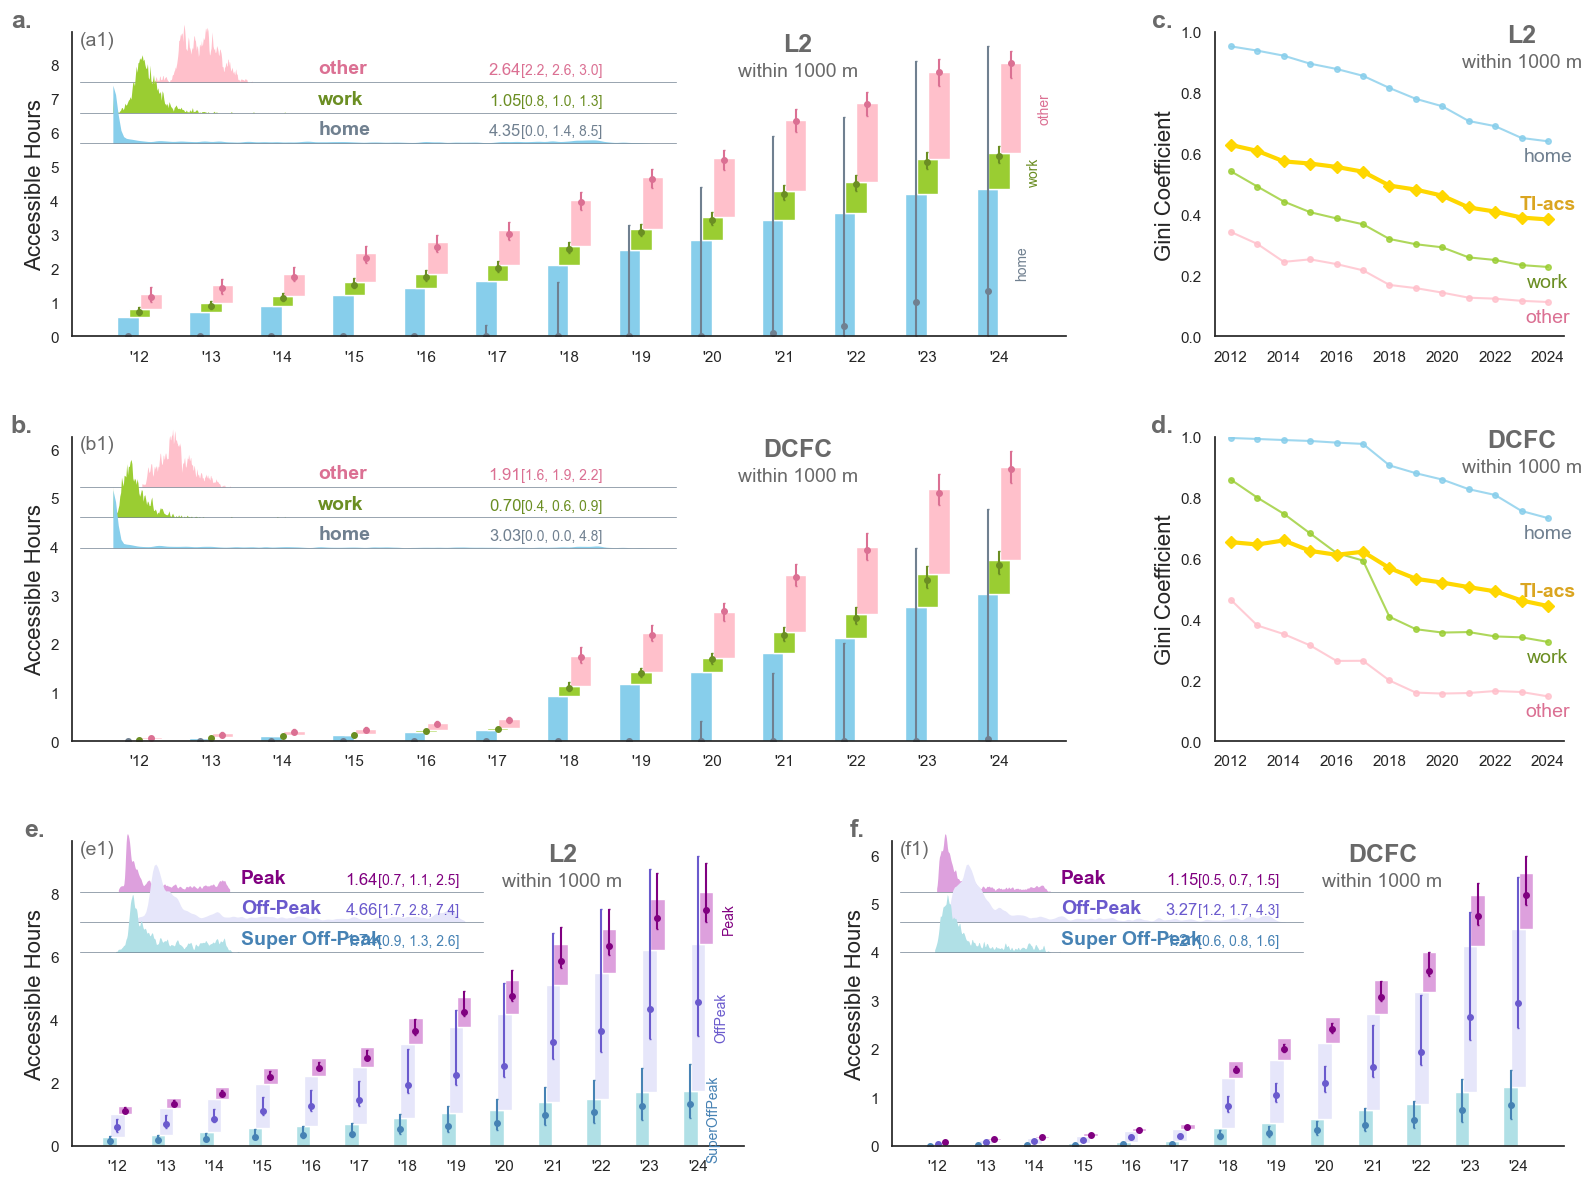

In [7]:
# Assemble Fig. 3 -------------------------------------------------------------
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 4, figure=fig, width_ratios=[2, 1, 1, 2])

for i, level in enumerate(["L2", "DCFC"]):
    # (a), (b): yearly location-segment bars + 2024 KDE inset
    ax = fig.add_subplot(gs[i, 0:3])
    mean_df, med_df, p25_df, p75_df = yearly_segment_stats(
        stats_annual, level, DIST_ANNUAL, "location", YEAR_RANGE)
    plotting.plot_breakdown_bars(
        ax, mean_df, med_df, p25_df, p75_df,
        segment_type="location", level=level, dist=DIST_ANNUAL,
        annotate=True, legend=(i == 0),
        x_labels=[f"\'{str(y)[-2:]}" for y in YEAR_RANGE],
    )

    # KDE insets: three transparent axes stacked vertically with overlapping
    # bbox offsets; each axes draws ONE segment's KDE on a transparent
    # background, so the three curves visually compose as in the original
    # Fig. 3 a1/b1.
    m_focus = segment_matrix(stats_annual, YEAR_FOCUS, level, DIST_ANNUAL, "location")
    x_max = max(m_focus[s].max() for s in ["home", "work", "other"]) * 1.05
    inset_axs = [inset_axes(ax, width="60%", height="20%",
                             bbox_to_anchor=(0, -0.1 * k + 0.06, 1, 1),
                             bbox_transform=ax.transAxes, loc="upper left")
                 for k in range(3)]
    for k, seg in enumerate(["other", "work", "home"]):
        plotting.plot_segment_kde(inset_axs[k], m_focus[seg], seg, "location",
                                  annotate=True, xlim=(-1.0, x_max))

    ax.text(-0.04, 1, chr(97 + i) + ".", fontsize=18, ha="right", va="bottom",
            fontweight="bold", color="dimgrey", transform=ax.transAxes)
    inset_axs[0].text(0.0, 0.85, f"({chr(97 + i)}1)", fontsize=14, ha="left",
                       va="top", color="dimgrey", transform=inset_axs[0].transAxes)

    # (c), (d): Gini trend
    ax_g = fig.add_subplot(gs[i, 3])
    gdf = gini_L2 if level == "L2" else gini_DC
    plotting.plot_gini_trend(ax_g, gdf, level=level, dist=DIST_ANNUAL)
    ax_g.text(-0.12, 1, chr(97 + i + 2) + ".", fontsize=18, ha="right",
              va="bottom", fontweight="bold", color="dimgrey", transform=ax_g.transAxes)

    # (e), (f): TOU bars + KDE inset
    ax_t = fig.add_subplot(gs[2, i * 2:i * 2 + 2])
    mean_t, med_t, p25_t, p75_t = yearly_segment_stats(
        stats_annual, level, DIST_ANNUAL, "tou", YEAR_RANGE)
    plotting.plot_breakdown_bars(
        ax_t, mean_t, med_t, p25_t, p75_t,
        segment_type="tou", level=level, dist=DIST_ANNUAL,
        annotate=True, legend=(i == 0),
        x_labels=[f"\'{str(y)[-2:]}" for y in YEAR_RANGE],
    )

    m_focus_t = segment_matrix(stats_annual, YEAR_FOCUS, level, DIST_ANNUAL, "tou")
    x_max_t = max(m_focus_t[s].max() for s in ["SuperOffPeak", "OffPeak", "Peak"]) * 1.05
    inset_axs_t = [inset_axes(ax_t, width="60%", height="20%",
                                bbox_to_anchor=(0, -0.1 * k + 0.06, 1, 1),
                                bbox_transform=ax_t.transAxes, loc="upper left")
                    for k in range(3)]
    for k, seg in enumerate(["Peak", "OffPeak", "SuperOffPeak"]):
        plotting.plot_segment_kde(inset_axs_t[k], m_focus_t[seg], seg, "tou",
                                  annotate=True, xlim=(-1.0, x_max_t))

    ax_t.text(-0.04, 1, chr(101 + i) + ".", fontsize=18, ha="right", va="bottom",
              fontweight="bold", color="dimgrey", transform=ax_t.transAxes)
    inset_axs_t[0].text(0.0, 0.85, f"({chr(101 + i)}1)", fontsize=14, ha="left",
                         va="top", color="dimgrey", transform=inset_axs_t[0].transAxes)

plt.tight_layout(h_pad=3, w_pad=5)
fig.savefig(os.path.join(FIG_DIR, "fig3_breakdown.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()


## Fig. 5 — Distance-threshold sensitivity (Discussion)

For each level (L2, DCFC), segment-partition (location, TOU) and distance (500, 1000, 2000, 3000 m), plot the breakdown across `YEARS_MULTIDIST`.


C:\Users\jerry\AppData\Local\Temp\ipykernel_32220\1747998953.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=-0.5)


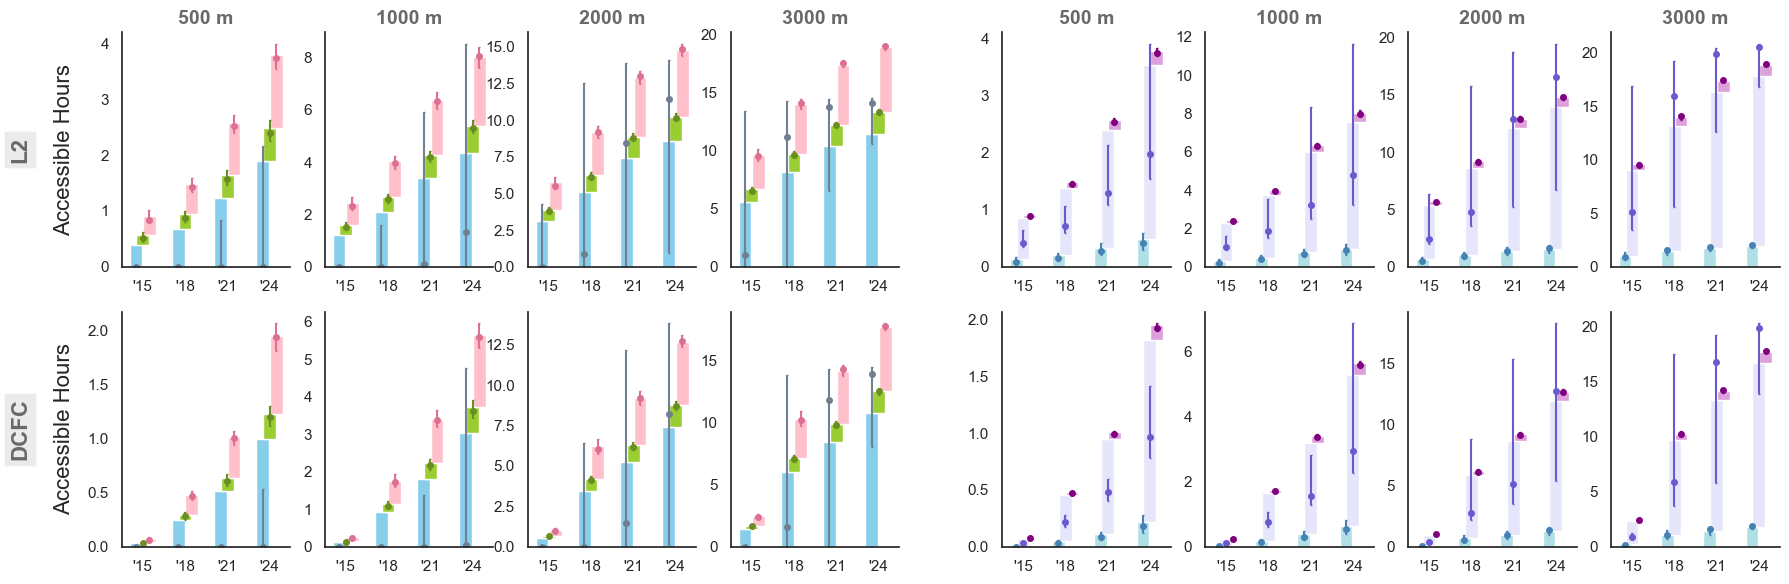

In [8]:
# Assemble Fig. 5 -------------------------------------------------------------
fig, axs = plt.subplots(2, 10, figsize=(18, 6),
                         width_ratios=([0.2] + [1] * 4) * 2,
                         constrained_layout=True)

for i, level in enumerate(["L2", "DCFC"]):
    for j in range(8):
        ax = axs[i, j + 1 + (j >= 4)]
        dist = DISTS_MULTIDIST[j % 4]
        seg = ["location", "tou"][j // 4]
        mean_df, med_df, p25_df, p75_df = yearly_segment_stats(
            stats_multidist, level, dist, seg, YEARS_MULTIDIST)
        plotting.plot_breakdown_bars(
            ax, mean_df, med_df, p25_df, p75_df,
            segment_type=seg, level=level, dist=dist,
            annotate=False, legend=False,
            x_labels=[f"\'{str(y)[-2:]}" for y in YEARS_MULTIDIST],
        )
        if i == 0:
            ax.set_title(f"{dist} m", fontsize=14, color="dimgrey", fontweight="bold")
        ax.set_ylabel("")

    # Row label
    ax = axs[i, 0]
    ax.axis("off")
    ax.text(-1, 0.5, level, fontsize=16, ha="center", va="center",
            fontweight="bold", color="dimgrey", rotation=90,
            bbox=dict(facecolor="silver", edgecolor="white", alpha=0.3))
    ax.text(0.3, 0.5, "Accessible Hours", fontsize=16, ha="center", va="center", rotation=90)
    # Spacer between location and TOU group
    axs[i, 5].axis("off")

plt.tight_layout(w_pad=-0.5)
fig.savefig(os.path.join(FIG_DIR, "fig5_sensitivity.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
